## 🌶️🌶️ Encrypting data

In some situations, you need to share data with a counterpart but you are restricted by a NDA, GDPR or other data protection schemes.

You can create an encrypted version of your data if you want to share the data without sharing specific information such as names of data subjects.

<font color='red'><b>WARNING</b></font>: 

In some cases, encryption is not sufficient. Think about the example below. In order to protect the personal data of employees, we are encrypting the names of the employees.

non-encrypted data:
<pre>
Name, Rank, Salary
Zoe, CEO, 1200000
Tania, Head of Finance, 345000
Misha, Data Scientist, 134000
...
</pre>

encrypted data:
<pre>
Name, Rank, Salary
ae55bdfc-7163-444a-8c0a-37a798996045, 8a285c1-085e-4b8f-822b-853323c6d7b4, 1200000
57eaa3ee-dc80-48eb-be20-d37b6a5e6f0c, 28a285c1-085e-4b8f-822b-853323c6d7b4, 345000
f31a27e3-5ef3-443d-a410-2fd60eff8611, b8ab4183-125a-42f9-ab93-7a4f805dbe34, 134000
...
</pre>

🌶️ <font color='red'>Question</font>: What's wrong with this data encryption approach?


# How to encrypt data in Python

Use case: 

- data analysis on a list of confidential amino acids
- the audience can see the analysis restuls but should not see the underlying raw data


Starting point:

- amino acids dataset (source: Kaggle)

Objective:

- encript the Molecular formula

In [ ]:
from uuid import uuid4
import pandas as pd



Let's load the data from a csv file in the data folder

In [8]:
df_aminos = pd.read_csv('../data/aminoacids.csv')

Let's run the basic data QA checks

In [9]:
df_aminos.shape

(22, 22)

In [10]:
df_aminos.sample(5)

,Name,Abbr,Letter,Molecular Weight,Molecular Formula,Residue Formula,Residue Weight,pKa1,pKb2,pKx3,...,VSC,P1,P2,SASA,NCISC,carbon,hydrogen,nitrogen,oxygen,sulfur
20,Tryptophan,Trp,W,204.23,C11H12N2O2,C11H10N2O,186.22,2.83,9.39,NaN,...,145.5,5.4,0.409,2.663,0.037977,11,12,2,2,0
17,Threonine,Thr,T,119.12,C4H9NO3,C4H7NO2,101.11,2.09,9.10,NaN,...,51.3,8.6,0.108,1.525,0.003352,4,9,1,3,0
16,Serine,Ser,S,105.09,C3H7NO3,C3H5NO2,87.08,2.21,9.15,NaN,...,29.3,9.2,0.062,1.298,0.004627,3,7,1,3,0
21,Tyrosine,Tyr,Y,181.19,C9H11NO3,C9H9NO2,163.18,2.20,9.11,10.07,...,117.3,6.2,0.298,2.368,0.023599,9,11,1,3,0
3,Glutamic acid,Glu,E,147.13,C5H9NO4,C5H7NO3,129.12,2.19,9.67,4.25,...,62.0,12.3,0.151,1.862,0.006802,5,9,1,4,0


In [11]:
df_aminos.describe()

,Molecular Weight,Residue Weight,pKa1,pKb2,pKx3,pl4,H,VSC,P1,P2,SASA,NCISC,carbon,hydrogen,nitrogen,oxygen,sulfur
count,22.000000,22.000000,21.000000,21.000000,7.000000,21.000000,2.000000e+01,20.000000,20.000000,20.000000,20.000000,20.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,136.740909,118.726364,2.160000,9.432857,7.880000,6.008095,1.110223e-17,72.545000,8.325000,0.175750,1.818600,0.035872,5.318182,9.681818,1.409091,2.500000,0.090909
std,29.387263,29.389193,0.239917,0.434927,3.358392,1.726159,9.997737e-01,36.364521,2.690505,0.097589,0.461453,0.065018,2.124379,2.533328,0.796366,0.672593,0.294245
min,75.070000,57.050000,1.820000,8.800000,3.650000,2.770000,-2.530000e+00,0.000000,4.900000,0.000000,0.881000,-0.036610,2.000000,5.000000,1.000000,2.000000,0.000000
25%,119.630000,101.620000,1.990000,9.130000,5.125000,5.600000,-7.500000e-01,43.925000,5.650000,0.123000,1.510750,0.004308,4.000000,7.250000,1.000000,2.000000,0.000000
50%,132.615000,114.600000,2.180000,9.390000,8.180000,5.740000,1.900000e-01,75.250000,8.350000,0.165500,1.836000,0.019669,5.000000,9.000000,1.000000,2.000000,0.000000
75%,148.690000,130.680000,2.320000,9.620000,10.300000,6.000000,6.825000e-01,95.575000,10.500000,0.223250,2.082500,0.044993,6.000000,11.000000,1.750000,3.000000,0.000000
max,204.230000,186.220000,2.830000,10.600000,12.480000,10.760000,1.380000e+00,145.500000,13.000000,0.409000,2.663000,0.239531,11.000000,14.000000,4.000000,4.000000,1.000000


Let's first clean up the columns to remove all spaces

In [12]:
df_aminos.columns = df_aminos.columns.str.replace(' ', '_')

In [13]:
df_aminos.sample(3)


,Name,Abbr,Letter,Molecular_Weight,Molecular_Formula,Residue_Formula,Residue_Weight,pKa1,pKb2,pKx3,...,VSC,P1,P2,SASA,NCISC,carbon,hydrogen,nitrogen,oxygen,sulfur
1,Cysteine,Cys,C,121.16,C3H7NO2S,C3H5NOS,103.15,1.96,10.28,8.18,...,44.6,5.5,0.128,1.461,-0.036610,3,7,1,2,1
10,Methionine,Met,M,149.21,C5H11NO2S,C5H9NOS,131.20,2.28,9.21,NaN,...,94.1,5.7,0.221,2.034,0.002683,5,11,1,2,1
21,Tyrosine,Tyr,Y,181.19,C9H11NO3,C9H9NO2,163.18,2.20,9.11,10.07,...,117.3,6.2,0.298,2.368,0.023599,9,11,1,3,0


In [14]:


df_aminos['Molecular_Formula_Encrypted'] = df_aminos['Molecular_Formula'].apply(lambda x: str(uuid4()))


Code explaination


.apply

```Python
.apply(lambda x: str(uuid4())):
```

.apply(): This method is used to apply a function along an axis of the DataFrame. In this case, it applies the function to each element in the 'Molecular_Formula' column.


lamba function 

```Python
lambda x: str(uuid4())
```

This is an anonymous function (lambda function) that takes one argument x (which represents each element in the 'Molecular_Formula' column) and returns a new UUID (Universally Unique Identifier) as a string. The uuid4() function generates a random UUID.

Let's check the output by showing the new columns along side the unecrypted formula

In [15]:
# using .iloc indexing to extract all row and the first 5 columns and the last column 
# then exacting 5 random samples
df_aminos.iloc[:, list(range(5)) + [-1]].sample(5)

,Name,Abbr,Letter,Molecular_Weight,Molecular_Formula,Molecular_Formula_Encrypted
8,Lysine,Lys,K,146.19,C6H14N2O2,9fd51293-e362-4668-a461-a69d87f61819
2,Aspartic acid,Asp,D,133.11,C4H7NO4,9af10902-a5c1-4958-a10f-27accfd18896
13,Proline,Pro,P,115.13,C5H9NO2,38663e05-7cb5-40f3-8ff8-e69c2bced74f
19,Valine,Val,V,117.15,C5H11NO2,48cc1538-4faa-4f6b-8866-eac95d2e64c2
20,Tryptophan,Trp,W,204.23,C11H12N2O2,bd8efed5-df7a-430c-af0d-f8d81cf6f593


we can now use the encrypted formula as a new index for our data


In [16]:
df_aminos.set_index('Molecular_Formula_Encrypted', inplace=True)

In [17]:

# extact the numerical columns of df_aminos as df_aminos_num
df_aminos_num = df_aminos.select_dtypes(include=['float64', 'int64'])



In [18]:
df_aminos_num.sample(5)

,Molecular_Weight,Residue_Weight,pKa1,pKb2,pKx3,pl4,H,VSC,P1,P2,SASA,NCISC,carbon,hydrogen,nitrogen,oxygen,sulfur
Molecular_Formula_Encrypted,,,,,,,,,,,,,,,,,
b2f606a6-cec2-46be-af5f-8ca6a199198c,165.19,147.18,1.83,9.13,NaN,5.48,1.19,115.5,5.2,0.290,2.228,0.037552,9,11,1,2,0
495606cc-7165-4da6-8632-06ff91d6f53b,75.07,57.05,2.34,9.60,NaN,5.97,0.48,0.0,9.0,0.000,0.881,0.179052,2,5,1,2,0
dd570860-86ba-4256-8d5c-0250b5fe1d38,89.10,71.08,2.34,9.69,NaN,6.00,0.62,27.5,8.1,0.046,1.181,0.007187,3,7,1,2,0
3a6b9cad-e16f-48dc-bfaa-600f00431c69,131.18,113.16,2.36,9.60,NaN,6.02,1.38,93.5,5.2,0.186,1.810,0.021631,6,13,1,2,0
ad014242-409b-48a1-8e73-189b4aa9d4c3,174.20,156.19,2.17,9.04,12.48,10.76,-2.53,105.0,10.5,0.291,2.560,0.043587,6,14,4,2,0


we can now proceed with our data analyis using this new encrypted dataset.

note: the data scientist can also link back the results to the original data since we have the mapping in the df_aminos dataframe

Let's produce a correlation heat map of all numerical values in our dataset

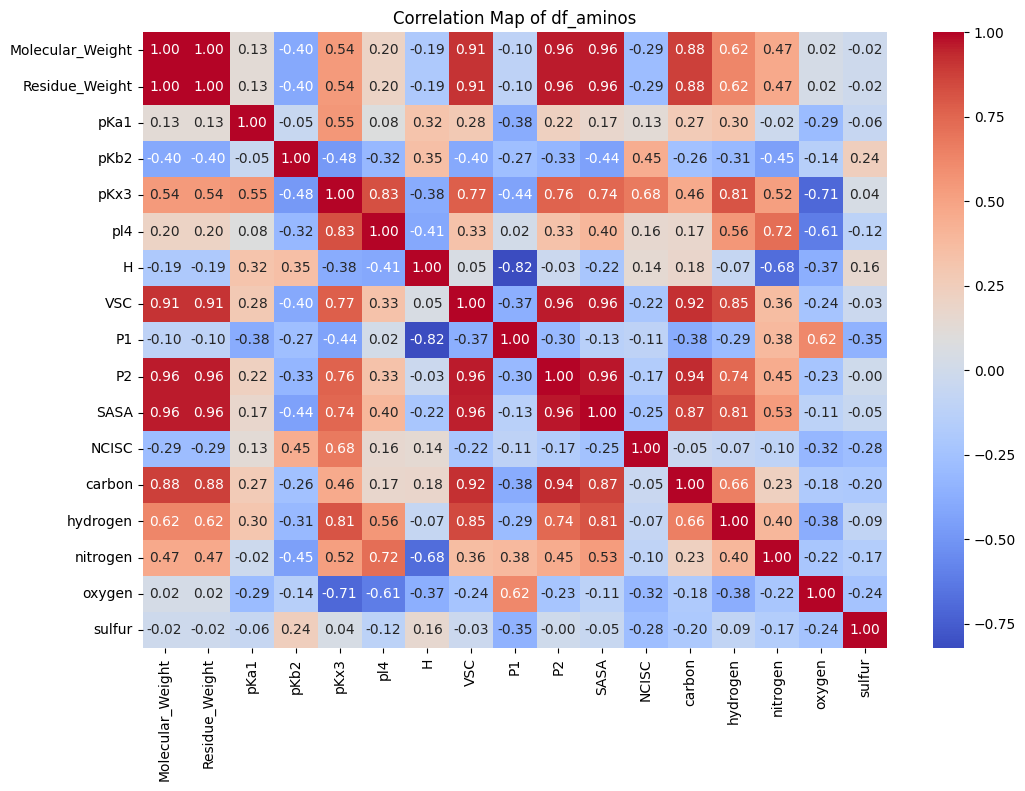

In [19]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr = df_aminos_num.corr()

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Map of df_aminos')
plt.show()